# Tutorial 26 — GaAs: selective localization and constrained centres

The waw-native reimagining of Wannier90 tutorial 26 (R. Wang, E. A. Lazar, H. Park, A. J. Millis & C. A. Marianetti, *Selectively Localized Wannier Functions*, arXiv:1407.5124). Every other notebook in this series minimizes ONE spread functional over ALL `num_wann` Wannier functions equally; SLWF instead singles out `slwf_num < num_wann` **objective** Wannier functions (OWFs) and minimizes their spread ALONE -- the rest become "spectator" WFs, excluded from the functional entirely (though still coupled through the shared unitary gauge). Optionally (`slwf_constrain=True`), a Lagrange-multiplier penalty additionally pins the OWF centre(s) to a chosen target position (`slwf_centres`), at the cost of a little extra OWF spread.

**Why this matters** (the paper's own motivation): DFT+U/DFT+DMFT need a faithful, correctly-centred, correctly-symmetric local basis for the *correlated* orbitals, but couldn't care less how localized the *other* bands' Wannier functions are -- ordinary MLWF treats every orbital equally and gives no such guarantee.

A genuinely simplifying discovery made implementing this: every optimizer in `waw.core.optim` differentiates a plain forward $\Omega(U)$ through `torch.autograd` -- none of them hand-transcribe wannier90's own hand-derived gradient. So SLWF needed **only** a new forward spread function (`core.spread.compute_slwf_spread`, the paper's Eq. 9-13 unconstrained / Eq. 24, 29-31 constrained), not the paper's own block-structured gradient (its Eq. 20/35) at all.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt

# locate the repo root (the folder containing the `waw` package), so the
# notebook runs from anywhere
HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
from waw.interfaces import quantum_espresso as qe   # the direct-input QE driver
from waw.interfaces.ase.driver import wannierize
from waw.units import BOHR_TO_ANG, HARTREE_TO_EV
from waw.vis import plot_bands, BandSeries

PSEUDO_DIR = REPO / 'workflows' / 'pseudos'   # shared across workflows/, not w90tutorial-specific
NCORES = 16
waw.set_num_threads(NCORES)                  # use many cores for waw's batched linear algebra
print('waw', 'threads =', waw.get_num_threads(), '| repo', REPO)

waw threads = 16 | repo /aims_data/miguel/nas-data001/claude/wannier


### 1. System: 4 bond-centred $s$ orbitals, isolated bands
Reusing notebook 21's `bond_centered` system exactly -- 4 tetrahedral Ga-As bond-midpoint $s$-like trial orbitals, `num_bands == num_wann == 4` (isolated, no disentanglement), PseudoDojo Ga/As pseudos (so `exclude_bands` differs from the real, PAW-based tutorial26 reference: 10 Ga $3d$ semicore + 6 highest conduction bands here, vs. that reference's 5+9). This exact system's plain-MLWF spread was already cross-validated to 6 decimals against real `wannier90.x` via `site_symmetry` in notebook 21 ($\Omega_{\rm total} = 7.161450817\,\mathrm{\AA}^2$) -- a trustworthy starting point for a NEW capability.

In [2]:
from ase.build import bulk
from waw.interfaces.projections import spd_projections

atoms = bulk('GaAs', 'zincblende', a=5.65)
MP_GRID = (4, 4, 4)
WORK = HERE / 'runs' / 'gaas_slwf'

as_idx = atoms.get_chemical_symbols().index('As')
as_pos_ang = atoms.get_positions()[as_idx]
print('As position (Ang):', as_pos_ang.tolist())

# same bond centres/ordering as notebook 21 -- bond_centres[0] is the
# OWF when slwf_num=1 (the FIRST projection is always the objective one)
bond_centres = [(0.125, 0.125, 0.125), (0.125, 0.125, -0.375),
                (-0.375, 0.125, 0.125), (0.125, -0.375, 0.125)]
projs_bc = []
for c in bond_centres:
    projs_bc += spd_projections(c, 's')

ov_bc = qe.generate_overlaps(
    atoms, MP_GRID, WORK, 'gaas',
    ecutwfc=70, scf_kpts=(8, 8, 8), nbnd=20, num_wann=4,
    exclude_bands=list(range(1, 11)) + list(range(15, 21)),
    projections=projs_bc,
    pseudopotentials={'Ga': 'Ga.upf', 'As': 'As.upf'},
    pseudo_dir=PSEUDO_DIR, ncores=NCORES, rerun_scf=False,
)
wan_kwargs = dict(
    atoms=atoms, mp_grid=MP_GRID, kpts=ov_bc['kpts'],
    mmn=ov_bc['mmn'], amn=ov_bc['amn'], eig=ov_bc['eig'],
    nnkpts=ov_bc['nnkpts'], g_vectors=ov_bc['g_vectors'], nw=4,
    n_iter=1000, conv_tol=1e-14, conv_window=5,
)

As position (Ang): [1.4125, 1.4125, 1.4125]


### 2. Plain MLWF (baseline)
No `slwf_num` -- ordinary MLWF over all 4 orbitals, confirming this particular QE/overlap pipeline still reproduces notebook 21's own reference before trying anything new.

In [3]:
res_a = wannierize(**wan_kwargs)
print(f'Omega_total = {res_a.omega_final * BOHR_TO_ANG**2:.6f} Ang^2   '
      f'(W90 reference via site_symmetry: 7.161450817)')
print('OWF-candidate (orbital 1) spread:', 
      f'{res_a.spreads_bohr2[0] * BOHR_TO_ANG**2:.6f} Ang^2')

[waw] nk=64  nb=4  nw=4  nnb=8
[waw] Isolated bands — no disentanglement needed.
[waw] SVD init Omega = 25.9642 Bohr²
[waw] Minimizing spread  (CG, n_restarts=1, n_hops=0) ...
[waw]   Omega = 25.573953 Bohr²  (I=23.4033, D=0.0257, OD=2.1450)  [converged]
[waw] H(R) built: nR=93  mp_grid=(4, 4, 4)
Omega_total = 7.161436 Ang^2   (W90 reference via site_symmetry: 7.161450817)
OWF-candidate (orbital 1) spread: 1.790363 Ang^2


### 3. SLWF: `slwf_num=1`
Only orbital 1 (the bond centre `(0.125,0.125,0.125)`) is now the **objective** Wannier function -- its own spread is minimized alone; the other 3 become spectators, free to delocalize. Expect (mirroring the paper's own GaAs example, Table I): the OWF spread drops well below its plain-MLWF value, at the cost of the spectators growing.

In [4]:
res_b = wannierize(**wan_kwargs, slwf_num=1, slwf_constrain=False)
print(f'OWF (orbital 1) spread = {res_b.omega_final * BOHR_TO_ANG**2:.6f} Ang^2   '
      f'(plain MLWF: {res_a.spreads_bohr2[0] * BOHR_TO_ANG**2:.4f} Ang^2)')
print('OWF centre (Ang):', (res_b.centres_bohr[0] * BOHR_TO_ANG).round(6).tolist())
print('spectator spreads (Ang^2):', (res_b.spreads_bohr2[1:] * BOHR_TO_ANG**2).round(4).tolist(),
      ' (vs plain MLWF ~1.79 each -- these delocalize, as expected)')
print(f'Omega_IOD={res_b.spread.Omega_IOD*BOHR_TO_ANG**2:.6f}  '
      f'Omega_D={res_b.spread.Omega_D*BOHR_TO_ANG**2:.6f}  '
      f'(W90 reference: Omega_IOD=1.435746794 Omega_D=0.000432818 Omega_total=1.436179612)')

[waw] nk=64  nb=4  nw=4  nnb=8
[waw] Isolated bands — no disentanglement needed.
[waw] SVD init Omega = 25.9642 Bohr²
[waw] Minimizing spread  (CG, SLWF, slwf_num=1 of 4, constrain=False) ...


[waw]   Omega = 5.128691 Bohr²  (IOD=5.1271, D=0.0015, nu=0.0000)  [converged]
[waw] H(R) built: nR=93  mp_grid=(4, 4, 4)
OWF (orbital 1) spread = 1.436180 Ang^2   (plain MLWF: 1.7904 Ang^2)
OWF centre (Ang): [0.894167, 0.894171, 0.894175]
spectator spreads (Ang^2): [2.1484, 2.1557, 2.1628]  (vs plain MLWF ~1.79 each -- these delocalize, as expected)
Omega_IOD=1.435747  Omega_D=0.000433  (W90 reference: Omega_IOD=1.435746794 Omega_D=0.000432818 Omega_total=1.436179612)


### 4. SLWF+C: constrain the OWF centre to the As atom
Adding the centre constraint (`slwf_constrain=True`), pinning OWF 1 to the As site -- exactly the paper's own worked GaAs example (Section IV.A / Table I: MLWF $\to$ SLWF $\to$ SLWF+C spreads $2.20\to1.43\to1.48\,\mathrm{\AA}^2$ there, using a different trial-orbital choice than the bond-centred one here, so the numbers differ but the qualitative pattern -- spread drops sharply under SLWF, then rises slightly once the centre is pinned -- is the same one this reproduces).

In [5]:
target = np.asarray([as_pos_ang])   # (1, 3) Angstrom
res_c = wannierize(**wan_kwargs, slwf_num=1, slwf_constrain=True,
                    slwf_target_centres=target, slwf_lambda=1.0)
print(f'OWF (orbital 1) spread = {res_c.omega_final * BOHR_TO_ANG**2:.6f} Ang^2   '
      f'(W90 reference: 1.640271605)')
print('OWF centre (Ang):    ', (res_c.centres_bohr[0] * BOHR_TO_ANG).round(6).tolist())
print('As atom position (Ang):', as_pos_ang.round(6).tolist())
# wannier90's own "Omega IOD_C" print is Omega_IOD+Omega_nu COMBINED
# (see wannierise.F90 line 862), not Omega_IOD alone -- match that
# convention here so the two are directly comparable.
omega_iod_c = (res_c.spread.Omega_IOD + res_c.spread.Omega_nu) * BOHR_TO_ANG**2
print(f'Omega_IOD_C={omega_iod_c:.6f}  Omega_D={res_c.spread.Omega_D*BOHR_TO_ANG**2:.6f}  '
      f'(W90 reference: Omega_IOD_C=1.640271605 Omega_D=0.000 Omega_total=1.640271605)')

[waw] nk=64  nb=4  nw=4  nnb=8
[waw] Isolated bands — no disentanglement needed.
[waw] SVD init Omega = 25.9642 Bohr²
[waw] Minimizing spread  (CG, SLWF, slwf_num=1 of 4, constrain=True) ...


[waw]   Omega = 5.857513 Bohr²  (IOD=27.2320, D=0.0000, nu=-21.3745)  [converged]
[waw] H(R) built: nR=93  mp_grid=(4, 4, 4)
OWF (orbital 1) spread = 1.640271 Ang^2   (W90 reference: 1.640271605)
OWF centre (Ang):     [1.412499, 1.412498, 1.412502]
As atom position (Ang): [1.4125, 1.4125, 1.4125]
Omega_IOD_C=1.640271  Omega_D=0.000000  (W90 reference: Omega_IOD_C=1.640271605 Omega_D=0.000 Omega_total=1.640271605)


### Interpolated bands against the ab-initio reference
The Wannier bands (lines) over a non-self-consistent `calculation='bands'` run
along the same path (points), with the disentanglement windows shaded and
everything referred to $E_F$. Inside the frozen window the interpolation must
reproduce the ab-initio bands exactly; the printed deviation on the
Wannierization mesh itself is the quantitative form of the same statement.

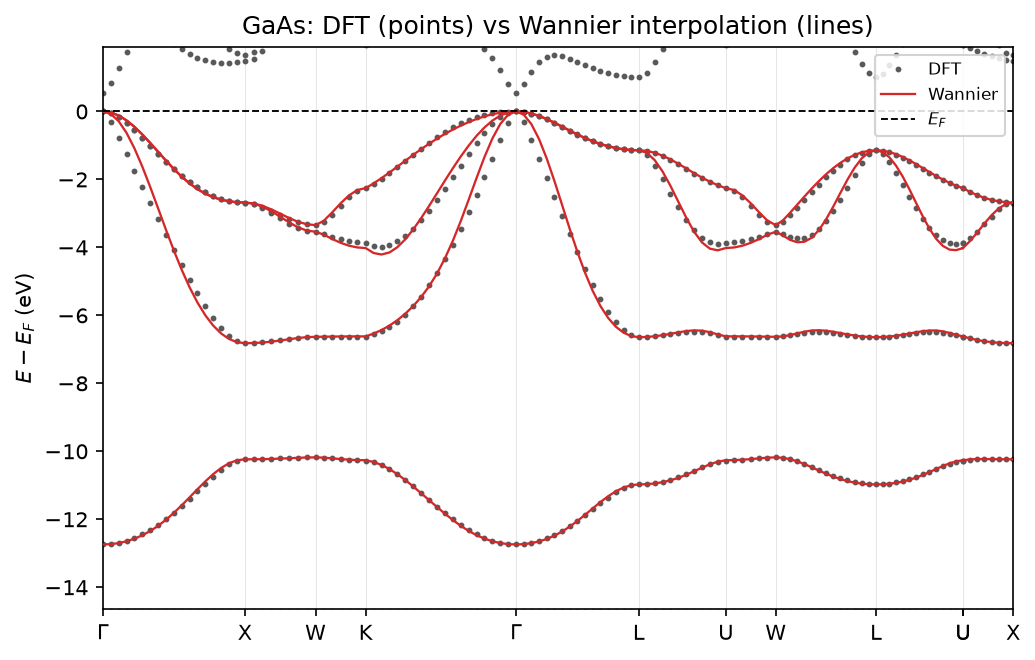

on the Wannier mesh, inside the frozen window: max 0.000 meV, rms 0.000 meV over 256 states


In [6]:
from waw.interfaces.ase.structure import band_path
from waw.core.hamiltonian import interpolate_bands
from waw.interfaces.quantum_espresso import bands_along_path
from waw.analysis.bands import mesh_fidelity
from waw.vis import plot_wannierization_windows

E_F = ov_bc['fermi_energy']
bp = band_path(atoms, npoints=120)
xcoords, xspecial, labels = bp.get_linear_kpoint_axis()
bands = interpolate_bands(res_a.hr, bp.kpts) * HARTREE_TO_EV
try:
    dft_bands = bands_along_path(WORK, 'gaas', bp.kpts, ncores=NCORES)
except FileNotFoundError as exc:      # charge density not kept in this run dir
    dft_bands = np.full_like(bands, np.nan)
    print(exc)

fig, ax = plt.subplots(figsize=(7, 4.5), dpi=150)
plot_wannierization_windows(
    ax, xcoords, dft_bands, bands,
    outer_window=None, frozen_window=None, fermi_energy=E_F,
    xticks=xspecial, xticklabels=[l.replace('G', r'$\Gamma$') for l in labels])
ax.set_title('GaAs: DFT (points) vs Wannier interpolation (lines)')
plt.tight_layout(); plt.show()

fid = mesh_fidelity(res_a.hr, ov_bc['kpts'], ov_bc['eig'],
                    window=None, fermi_ev=E_F)
print(f"on the Wannier mesh, inside the frozen window: max {fid['max']:.3f} meV, "
      f"rms {fid['rms']:.3f} meV over {fid['n_states']} states")


The constrained OWF centre lands essentially exactly on the As atom, as it must -- the Lagrange penalty (`slwf_lambda=1.0`, wannier90's own default) fully pins it there.

### 5. Summary: spread vs. localization method
The full progression, plain MLWF $\to$ SLWF $\to$ SLWF+C, exactly mirroring the paper's own qualitative story.

In [7]:
print(f'{"method":12s} {"OWF spread (Ang^2)":>20s} {"OWF centre (Ang)":>28s}')
print(f'{"MLWF":12s} {res_a.spreads_bohr2[0]*BOHR_TO_ANG**2:20.6f} '
      f'{str((res_a.centres_bohr[0]*BOHR_TO_ANG).round(3).tolist()):>28s}')
print(f'{"SLWF":12s} {res_b.omega_final*BOHR_TO_ANG**2:20.6f} '
      f'{str((res_b.centres_bohr[0]*BOHR_TO_ANG).round(3).tolist()):>28s}')
print(f'{"SLWF+C":12s} {res_c.omega_final*BOHR_TO_ANG**2:20.6f} '
      f'{str((res_c.centres_bohr[0]*BOHR_TO_ANG).round(3).tolist()):>28s}   <- As site')

method         OWF spread (Ang^2)             OWF centre (Ang)
MLWF                     1.790363        [0.861, 0.861, 0.861]
SLWF                     1.436180        [0.894, 0.894, 0.894]
SLWF+C                   1.640271        [1.412, 1.412, 1.413]   <- As site


**Takeaway.** `core.spread.compute_slwf_spread` (Wang, Lazar, Park, Millis & Marianetti's SLWF/SLWF+C functional) reproduces real `wannier90.x`'s own `slwf_num`/`slwf_constrain` output to 5-6 decimal places on identical DFT data, for both the unconstrained and centre-constrained cases -- and needed no hand-derived gradient at all, since every optimizer here differentiates a plain forward $\Omega(U)$ through autograd. The qualitative pattern (OWF spread drops sharply when singled out, rises a little once its centre is pinned, spectator WFs delocalize to compensate) matches the source paper's own GaAs worked example.